FAISS : (Facebook AI Similarity Searc)
FAISS is an open source library developed by meta for performing fast similarity search on dense vector embeddings . it also suppourts vector clustering .


example workflow :

User Query

     │
     ▼
     
Embedding Model

     │
     ▼
     
Query Vector

     │
     ▼
      FAISS
      
(Searches millions of vectors)

     │
     ▼
     
Most Similar Documents

* this is one of the core building blocks for RAG (Retrieval Argumented Generation) pipeline 

--- 
CPU vs GPU : 
FAISS can run on CPU and GPU 
* CPU -> good for most projects and laptops 
* GPU -> much faster for millions of vectors if we have a GPU

INSTALLATION :
* $ pip install faiss-cpu (for CPU)\
  
* $ pip install faiss-gpu (for GPU)

we install only one based on our hardware 

In [3]:
pip install faiss-cpu

Note: you may need to restart the kernel to use updated packages.


---
INDEXING : 
indexing is the process of organizing vector embeddings so FAISS can find the nearest vectors quickly without comparing the query against every vector in the database . 

| Number of Vectors | Without Index | With Index      |
| ----------------- | ------------- | --------------- |
| 1,000             | Fast          | Fast            |
| 100,000           | Slower        | Fast            |
| 1 Million         | Very slow     | Much faster     |
| 100 Million       | Impractical   | Still practical |


--- 
REAL WORLD ANALOGY (LIBRARY EXAMPLE ) :
when we go and ask for a book in the library , 
* without index : the librarian looks for each and every book in the library to find the book we asked for .
* with index : the librarian knows where the book is and he goes there and fetches it 

--- 
---
DIFFERENT TYPES OF INDEXES :
different types of indexes are designed for different goals 
we have to check which ones best for us and pick the one suitable for the use case

| Index    | How it works                                                         | Pros           | Cons                   | Best Use Case                 |
| -------- | -------------------------------------------------------------------- | -------------- | ---------------------- | ----------------------------- |
| **Flat** | Compares the query with **every vector**                             | 100% accurate  | Slow                   | Small datasets, exact results |
| **IVF**  | Divides vectors into clusters and searches only the relevant cluster | Much faster    | Slightly less accurate | Medium to large datasets      |
| **HNSW** | Creates a graph connecting similar vectors                           | Extremely fast | Uses more RAM          | Low-latency applications      |
| **PQ**   | Compresses vectors before storing them                               | Saves memory   | Lower accuracy         | Very large datasets           |


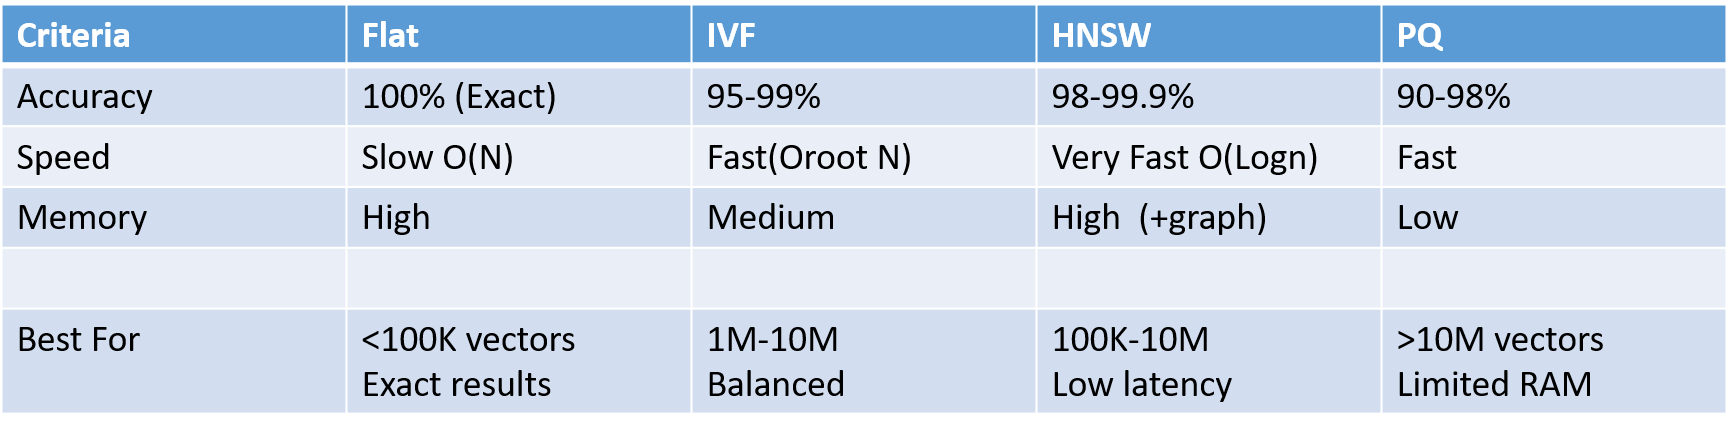

---
FLOAT :
imagine we have these vectors 

A
B
C
D
E
F
G

query arrives 'Q'

flat search does this - every vector is checked 

Q → A

Q → B

Q → C

Q → D

Q → E

Q → F

Q → G

characteristics :
* 100 % accurate
* but becomes slow as the data grows
* time complexity - O(N)

---
IVF (INVERTED FILE INDEX) :
instead of one huge list , vectors are grouped into clusters . 

Cluster 1

  A B C

Cluster 2

  D E F

Cluster 3

  G H I

suppose the query belongs to cluster 2 , so instead of searching all the vectors A B C D E F G H I , FAISS only searches DEF . this reduces the work dramatically 

characteristics :
* faster
* medium memroy
* may miss the absolute nearest vector
* time complexity - O(sqrt(N))

--- 
HNSW (HIERARCHIAL NAVIGABLE SMALL WORLD):
this is a clever one . instead of clusters , every vector is connected to a nearby vectors like a social network . 

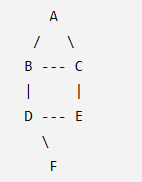

suppose the query is near F , 
FAISS starts somewhere and walks through the graph 

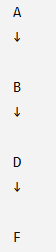

instead of checking everything , it just follows the shortest path 

characteristics :
* extremely fast
* highly accurate
* uses more ram , because all connections must be stored
* time complexity - O(log N)

this is why HNSW is populat for chatbots and semantic search 

--- 
PQ (PRODUCT QUANTIZATION):
 PQ compares vectors 

suppose a vector is 

[1.2546

 2.9854

 8.6234
 
 5.4567]

 instead of storing full precision , it rounds off the numbers 

[1.3

3.0

8.6

5.5] 

now the vector occupies much less memory . instead of 100 GB , we might only need 10 GB 

COMPRESSION PROCESS :
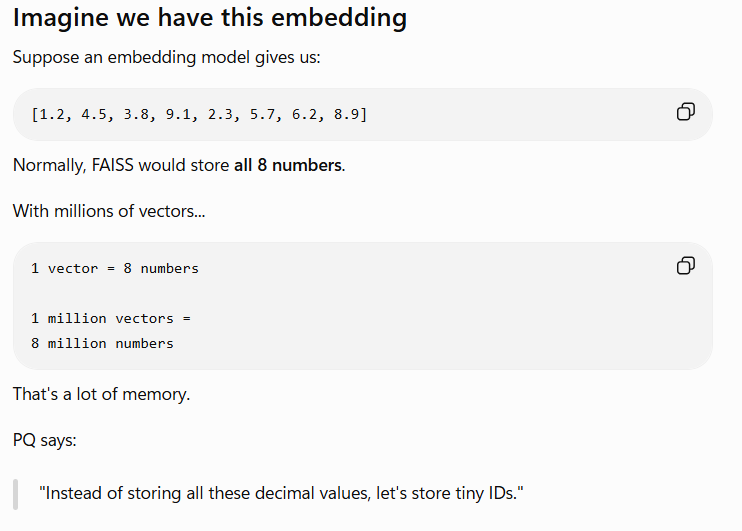
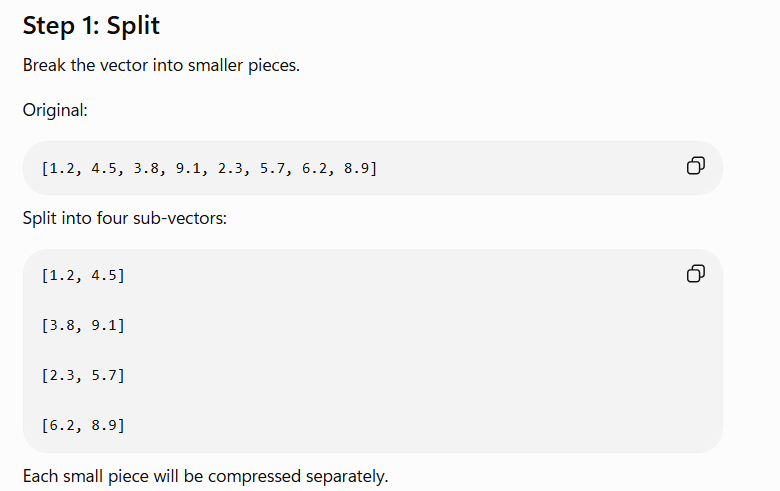
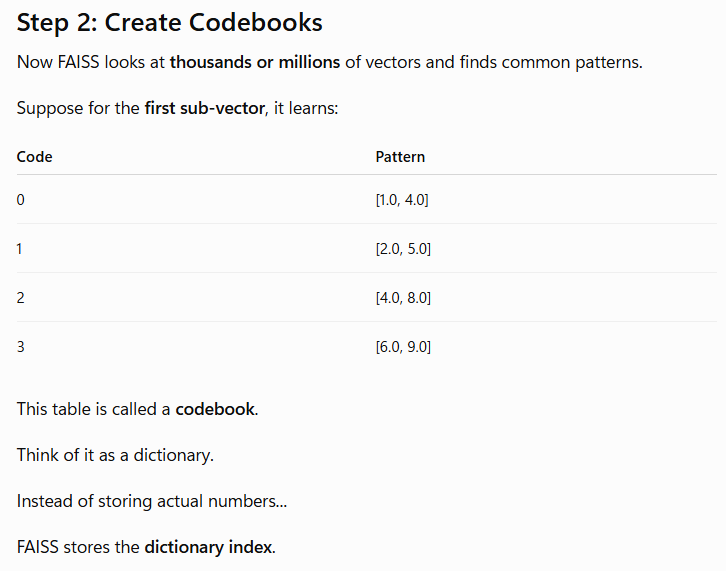
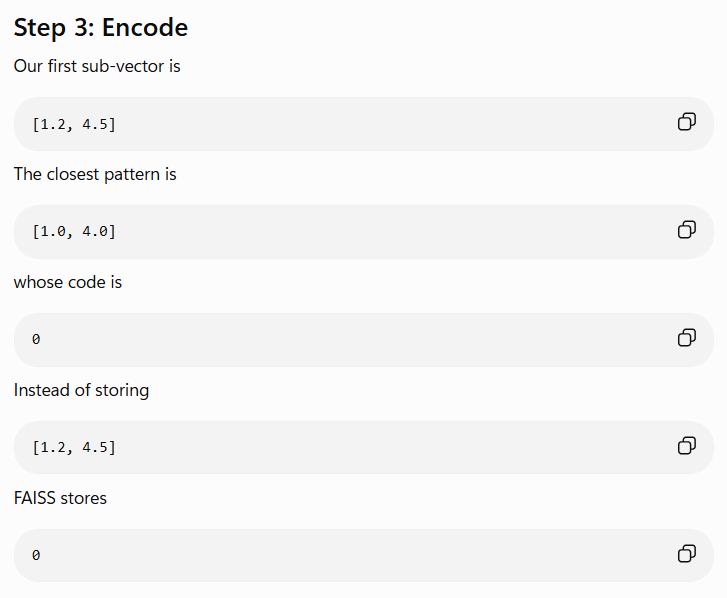
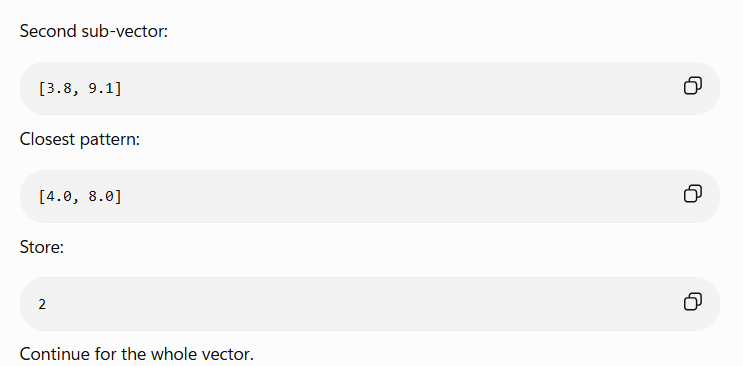
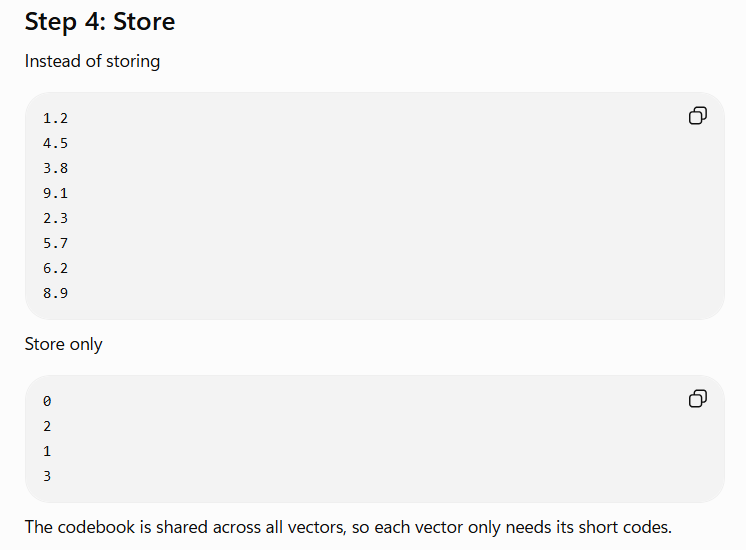


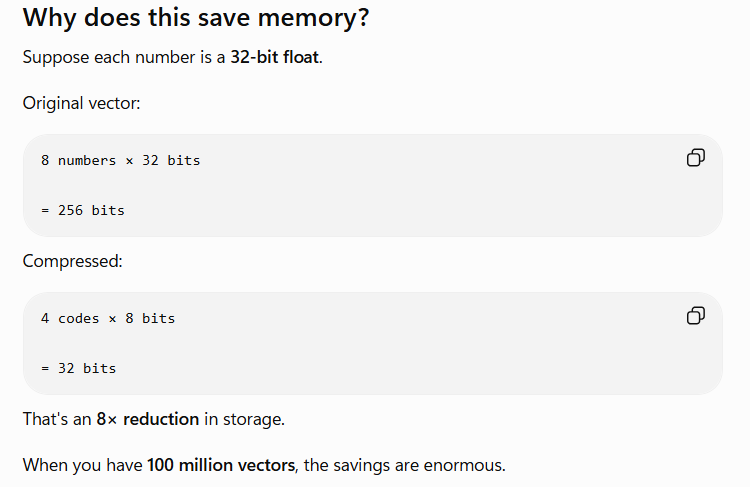

characteristics :
* lowest memory usage
* handles huge datasets
* some accuracy is lost because the vectors are approximated . 